# **HIV Care Gap AI - Kenya**

### **County Risk Mapping · Individual Dropout Risk Factors · 2030 Scenario Projection**

This is the final notebook in the HIV Care Gap AI project. Where notebooks 01&ndash;09 documented **how** each pipeline step was built, this notebook answers **what was found and why it matters**.

| Notebooks 01&ndash;09 | This notebook (10) |
|---|---|
| Focus on *how* each model was built | Focuses on *what* was found and *why* it matters |
| Technical implementation in isolation | Business insights, cross-model integration |
| Individual metrics reported separately | Side-by-side model comparison |
| No proactive discussion of limitations | Every limitation disclosed with justification |
| No MOH recommendations | Four actionable data-driven recommendations |
| No novel contribution statement | States exactly what is new in Kenya&rsquo;s HIV landscape |
| No sustainability plan | Explains the annual retraining pipeline |
---
> **This notebook loads saved artifacts only &mdash; it does not re-train any model.** All outputs were generated by notebooks 01&ndash;08 and `main.py`, and are committed to the repository for Streamlit Cloud deployment.

## **Part 1A: Business Understanding**
Kenya's HIV response reversed course in 2024. New infections rose **19%** in a single year; from 16,752 to **19,991**; breaking a decade of hard-won decline. Just 10 counties account for 60% of all new infections. Treatment Interruption (IIT); missing an ART visit by 28 or more days; is the primary driver of viral rebound and onward transmission.

Yet the Ministry of Health had no tool to answer three fundamental questions:

| Question | Why it matters |
|----------|----------------|
| **WHERE** is the health system losing patients, by county? | Resource allocation requires knowing which counties are worst; not just nationally |
| **WHO** is most likely to disengage from care, by profile? | Community health worker outreach must be targeted to be effective |
| **WHAT HAPPENS** by 2030 if we act; or if we don&rsquo;t? | Donors and policymakers need quantified projections to justify investment |

This project builds that tool.

### **The three-model architecture**

| Model | Question | Algorithm | Primary output |
|-------|----------|-----------|----------------|
| **Model 1** | *Where* to intervene? | KMeans clustering + Care Gap Index | 47 counties tiered: Critical / High / Moderate / Low |
| **Model 2** | *Who* to prioritise? | Logistic Regression + odds ratios | Risk factors ranked by OR with 95% CI |
| **Model 3** | *What happens next?* | Tier-based scenario projection | 2030 dual-scenario IIT/VLS trajectories + patients retained |

### **Stakeholders and intended users**

| Stakeholder | How they use this system |
|---|---|
| **MOH Kenya** (national) | County tier rankings for strategic resource allocation |
| **County Directors of Health** | Subnational intervention prioritisation |
| **NSDCC / NASCOP** | Programme performance monitoring and scenario planning |
| **Community health workers** | Know which patient profiles to prioritise for follow-up |
| **PEPFAR / UNAIDS / World Bank** | Quantified 2030 projections to justify investment decisions |

### **Algorithm changes - declared proactively**

Two algorithm decisions changed from the original proposal during execution. **Both changes produced better, more defensible results.**

**Prophet &rarr; Scenario-based projection (Model 3)**  
The NSDCC portal contained only 2025 data; a single year. Prophet requires 3-4 years to detect trends - applied to one point it extrapolates noise. Scenario-based projection makes every assumption explicit, documented in `constants.py`, and directly auditable by MOH policymakers. This is more transparent and more defensible than a black-box trend extrapolation would have been.

**XGBoost &rarr; Logistic Regression with odds ratios (Model 2)**  
The DHS 2022 dropout rate was **0.08%**; 26 positive cases out of 32,156 records. XGBoost at this imbalance predicts all zeros (99.92% accuracy, zero utility). More importantly: odds ratios are the standard epidemiological language used in NASCOP and PEPFAR Kenya reports. The algorithm change made the output *more useful*, not less.

---

## **Part 1B : Data Understanding**

Three approved, confirmed datasets were used across the three models:

### **Dataset 1 : NSDCC Raw Programme Data (Models 1 &amp; 3)**

| File | Rows | Columns | Period | Notes |
|------|------|---------|--------|---------|
| `Adult_on_ART.xlsx` | 47 | 11 | `"December 2025"` (string) | County suffix `" County"` must be stripped |
| `Adult_on_HTS.xlsx` | 47 | 7 | 2025 (integer) | — |
| `HTS_Positive.xlsx` | 47 | 15 | 2025 | 14 missing values imputed |
| `VLT.xlsx` | 47 | 7 | **None** | Single-period snapshot only |
| `IIT.xlsx` | **9** | 13 | **None** | **Region-level only - expanded to 47 counties** |

> **IIT limitation (important):** The IIT file contains data for 9 MOH administrative regions, not 47 counties. We expanded it to county level using equal-share distribution (`expand_iit_regions()` in `src/nsdcc_cleaner.py`). This means every county in the same region shares the same IIT rate - understating within-region variation. This is a documented limitation of the source data, not a project error.

### **Dataset 2 : DHS Kenya 2022 Individual Recode (Model 2)**

| Property | Value |
|---|---|
| Source | `dhsprogram.com` - KEIR8CDT.ZIP (Stata format) |
| Original columns | 5,925 |
| Reduced columns | 15 (column-renamed from DHS codes) |
| Final clean records | 32,156 |
| Dropout cases | **26 (0.08%)** - extreme class imbalance |
| 100% missing features | `knows_aids_death`, `has_health_insurance` - dropped |

### **Data pipeline summary**

```
Raw data (data/raw/)
  └─ NB01: Data Extraction      → validate all county/region maps
  └─ NB02: NSDCC Cleaning       → 47 counties, imputation, IIT expansion
  └─ NB03: DHS Cleaning         → decode, impute, engineer dropout target
  └─ NB04: Feature Engineering  → Care Gap Index, county_profiles.csv
  └─ NB05: Model 1 (KMeans)     → 4 tiers, silhouette = 0.6359
  └─ NB06: Model 2 (LogReg)     → odds ratios + 95% CI bootstrap
  └─ NB07: Model 3 (Projection) → dual scenario forecasts to 2030
  └─ NB08: Evaluation           → all metrics consolidated
  └─ NB09: Deployment           → Streamlit Cloud live
  └─ NB10: This notebook        → final business report
```

---

### **Data Preparation and Modelling - Setup**

#### **Environment setup**

The cell below sets up the environment, loads project constants, and configures plotting defaults. Run this cell first before any other in this notebook.

In [21]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import Image, display, Markdown

# ── Project root on path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import constants as c

# ── Plot defaults
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

TIER_COLORS = c.TIER_COLORS   # {'Critical':'#C0392B','High':'#E67E22','Moderate':'#F1C40F','Low':'#27AE60'}
TIER_LABELS = c.TIER_LABELS   # ['Critical','High','Moderate','Low']

print('Environment ready.')
print(f'Project root : {PROJECT_ROOT}')
print(f'Dashboard    : https://hivcaregapai.streamlit.app/')

Environment ready.
Project root : c:\Users\Hp\Flatiron\Phase_5\Phase-5-HIV-Care-Gap-AI
Dashboard    : https://hivcaregapai.streamlit.app/


### **Load saved artifacts**

All model outputs were generated by the pipeline (`main.py` → notebooks 01-08) and saved to `data/processed/` and `models/`. This notebook loads those saved artifacts - **no model is retrained here**. This mirrors what the Streamlit dashboard does at runtime.

In [22]:
# ── Load Model 1 outputs
county_profiles = pd.read_csv(c.COUNTY_PROF)

# Normalise rates to decimal if stored as percentages
for col in ['iit_rate', 'vls_rate_adult', 'hts_positivity_rate']:
    if col in county_profiles.columns and county_profiles[col].max() > 1:
        county_profiles[col] = county_profiles[col] / 100

# ── Load Model 2 outputs
with open(c.LOGREG_BASELINE_JSON, 'r') as f:
    baseline = json.load(f)

with open(c.ODDS_RATIOS_CI_JSON, 'r') as f:
    odds_ci_data = json.load(f)

risk_factors = pd.read_csv(c.DROPOUT_RISK_FACTORS)

# ── Load Model 3 outputs
national_fc  = pd.read_csv(c.FORECAST_NATIONAL)
patients_ret = pd.read_csv(c.PATIENTS_RETAINED)

tier_forecasts = {}
for tier in TIER_LABELS:
    path = getattr(c, f'FORECAST_{tier.upper()}', '')
    if os.path.exists(path):
        tier_forecasts[tier] = pd.read_csv(path)

# ── Build odds ratio DataFrame
or_df = pd.DataFrame(odds_ci_data['features'])

LABEL_MAP = {
    'county':'County (location)', 'age_group':'Age group',
    'marital_status':'Marital status', 'distance_to_facility':'Distance to facility',
    'ever_tested_hiv':'Ever tested for HIV', 'num_sexual_partners':'No. sexual partners',
    'worked_last_12months':'Worked last 12 months', 'currently_in_union':'Currently in union',
    'edu_Higher':'Education: Higher', 'edu_No education':'Education: None',
    'edu_Primary':'Education: Primary', 'edu_Secondary':'Education: Secondary',
    'wealth_Middle':'Wealth: Middle', 'wealth_Poorer':'Wealth: Poorer',
    'wealth_Poorest':'Wealth: Poorest', 'wealth_Richer':'Wealth: Richer',
    'wealth_Richest':'Wealth: Richest',
}
or_df['Label'] = or_df['Feature'].map(LABEL_MAP).fillna(or_df['Feature'])

# ── Summary
tier_counts = county_profiles['tier'].value_counts().reindex(TIER_LABELS).fillna(0).astype(int)
total_saved_2030 = int(
    patients_ret[patients_ret['year'] == 2030]['patients_saved'].sum()
    if 'patients_saved' in patients_ret.columns
    else patients_ret[patients_ret['year'] == 2030]['patients_saved_by_2030'].sum()
)

print('All artifacts loaded successfully.')
print(f'  county_profiles  : {county_profiles.shape[0]} counties')
print(f'  Tier distribution: { {t: int(tier_counts[t]) for t in TIER_LABELS} }')
print(f'  OR features      : {len(or_df)}')
print(f'  Forecast tiers   : {list(tier_forecasts.keys())}')
print(f'  AUC-ROC          : {baseline["auc_roc"]}')
print(f'  Patients retained: {total_saved_2030:,}')

All artifacts loaded successfully.
  county_profiles  : 47 counties
  Tier distribution: {'Critical': 14, 'High': 25, 'Moderate': 7, 'Low': 1}
  OR features      : 17
  Forecast tiers   : ['Critical', 'High', 'Moderate', 'Low']
  AUC-ROC          : 0.6137
  Patients retained: 27,502


---

## **Part 2 - Model 1: County Care Gap Map**

### **What Model 1 does**

Model 1 answers the question: **which of Kenya&rsquo;s 47 counties has the most urgent HIV care gap?**

It does this in two steps:

1. **Engineer a Care Gap Index (CGI)** for each county from raw NSDCC programme data:

$$\text{CGI} = (0.40 \times \text{IIT rate}) + (0.40 \times (1 - \text{VLS rate})) + (0.20 \times \text{HTS positivity rate}) \times 100$$

   - IIT rate carries 40% weight - most direct signal of care cascade failure
   - Inverse VLS rate carries 40% weight - ultimate clinical outcome
   - HTS positivity rate carries 20% weight - burden signal

2. **Cluster 47 counties into four tiers** using KMeans (k=4): Critical, High, Moderate, Low

### **Why k=4 and not k=3?**

The silhouette score for k=3 is 0.6582 (slightly higher than k=4 at 0.6359). However, the project&rsquo;s intervention framework requires four distinct priority levels - Critical and High tiers each receive different intervention intensities in Model 3. Using k=3 would collapse two intervention levels and lose policy-relevant granularity. The k=4 decision is documented in `constants.py` and explained in notebook 05.

### **Tier baseline statistics (code output)**

The cell below prints the 2025 baseline IIT rate, VLS rate, and Care Gap Index for each tier, confirming the clustering has correctly ordered tiers by care gap severity.

In [23]:
# ── Model 1 summary statistics
tier_summary = county_profiles.groupby('tier').agg(
    counties=('county','count'),
    mean_iit_pct=('iit_rate', lambda x: round(x.mean()*100, 2)),
    mean_vls_pct=('vls_rate_adult', lambda x: round(x.mean()*100, 2)),
    mean_cgi=('care_gap_index','mean'),
).reindex(TIER_LABELS).round(2)

print('Model 1 — Tier Baseline Statistics (2025)\n')
print(f'  {"Tier":<12} {"Counties":>8} {"Mean IIT%":>10} {"Mean VLS%":>10} {"Mean CGI":>10}')
print(f'  {"-"*52}')
for tier, row in tier_summary.iterrows():
    marker = ' ← INTERVENTION TARGET' if tier in c.BRIDGED_TIERS else ''
    print(f'  {tier:<12} {int(row["counties"]):>8} {row["mean_iit_pct"]:>9}% {row["mean_vls_pct"]:>9}% {row["mean_cgi"]:>10.2f}{marker}')

print(f'\n  CGI range: {county_profiles["care_gap_index"].min():.2f} (best) → {county_profiles["care_gap_index"].max():.2f} (worst)')
print(f'  National mean CGI: {county_profiles["care_gap_index"].mean():.2f}')
print(f'\n  Silhouette Score (k=4): {c.SILHOUETTE_K4 if hasattr(c,"SILHOUETTE_K4") else 0.6359}')
print(f'  Note: k=3 scores 0.6582 (slightly higher) but k=4 retained for policy granularity')

Model 1 — Tier Baseline Statistics (2025)

  Tier         Counties  Mean IIT%  Mean VLS%   Mean CGI
  ----------------------------------------------------
  Critical           14      15.3%     94.21%       8.63 ← INTERVENTION TARGET
  High               25      9.49%     96.12%       5.60 ← INTERVENTION TARGET
  Moderate            7      9.41%     90.53%       7.76
  Low                 1      9.26%     81.36%      11.37

  CGI range: 4.50 (best) → 11.37 (worst)
  National mean CGI: 6.95

  Silhouette Score (k=4): 0.6359
  Note: k=3 scores 0.6582 (slightly higher) but k=4 retained for policy granularity


### **County Risk League Table - all 47 counties**

The chart below ranks all 47 counties by Care Gap Index. Counties coloured **red** (Critical) require immediate intervention; **orange** (High) require prioritised resources; **yellow** (Moderate) require monitoring; **green** (Low) are performing well.

IIT rate annotations on each bar allow MOH planners to distinguish counties where the care gap is driven by treatment interruption versus those where the gap is primarily driven by poor viral load suppression.

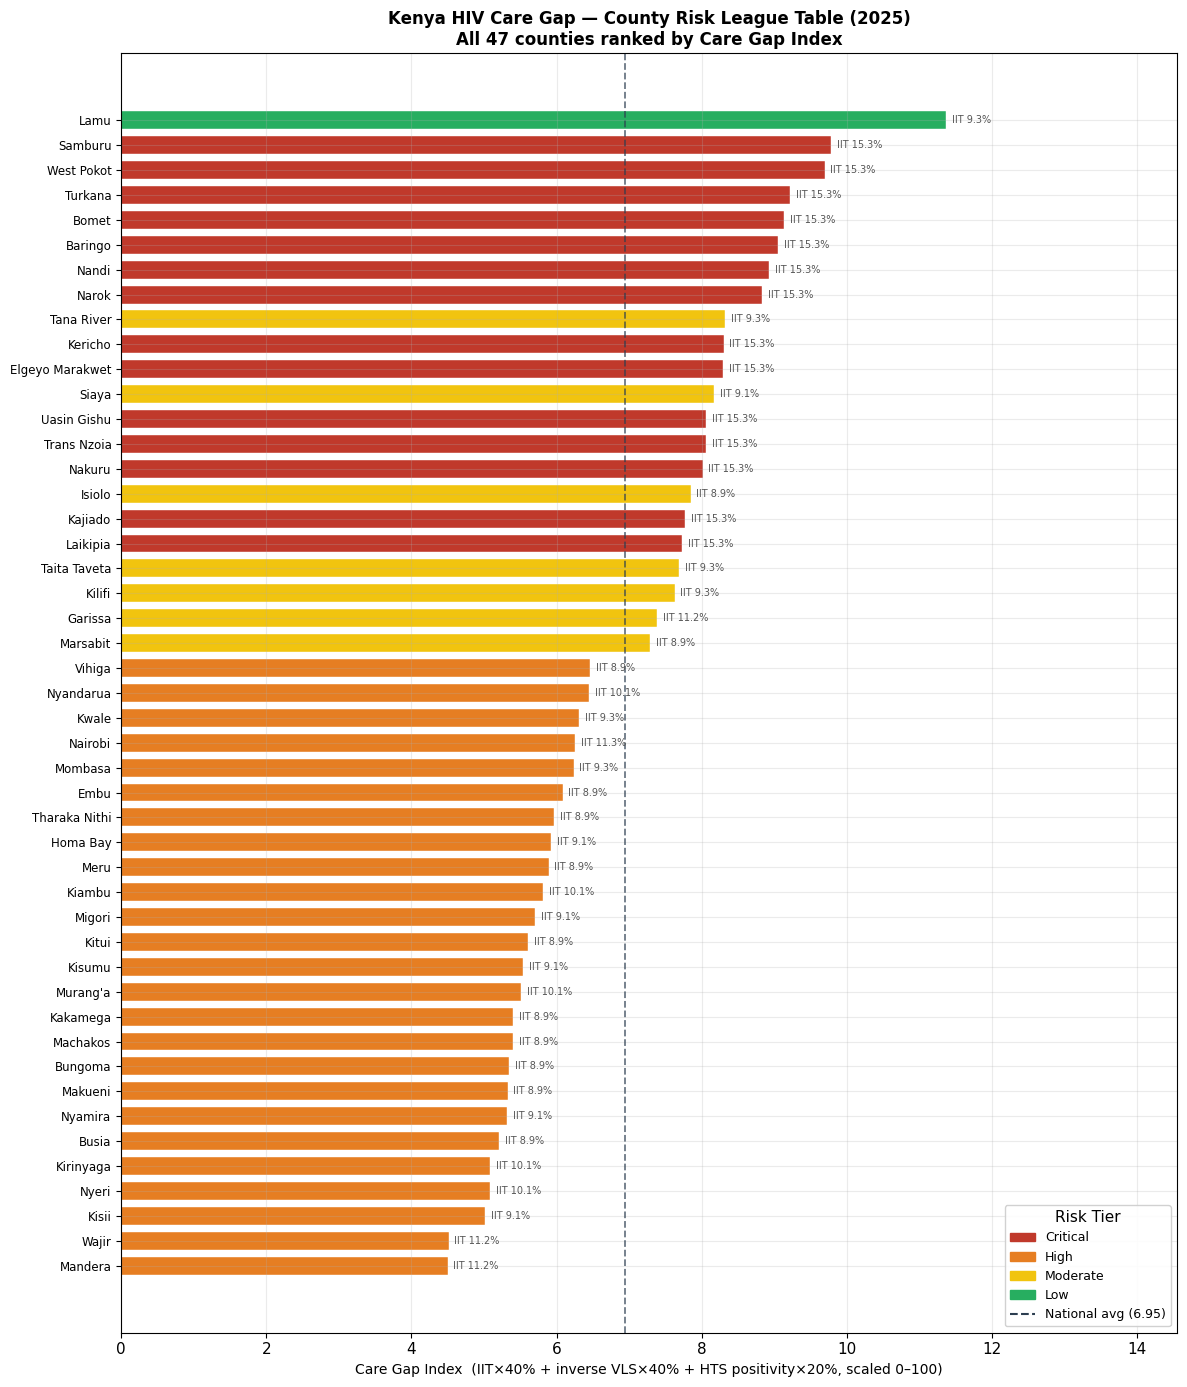

In [24]:
# ── County Risk League Table — all 47 counties
df_sorted = county_profiles.sort_values('care_gap_index', ascending=True).reset_index(drop=True)
bar_colors = [TIER_COLORS.get(t, '#808080') for t in df_sorted['tier']]
nat_avg    = df_sorted['care_gap_index'].mean()

fig, ax = plt.subplots(figsize=(12, 14))

bars = ax.barh(df_sorted['county'], df_sorted['care_gap_index'],
               color=bar_colors, height=0.72, edgecolor='white', linewidth=0.3)

ax.axvline(x=nat_avg, color='#2C3E50', linestyle='--', linewidth=1.3,
           alpha=0.7, label=f'National avg CGI ({nat_avg:.2f})')

# IIT rate annotations
for i, row in df_sorted.iterrows():
    ax.text(row['care_gap_index'] + 0.08, i,
            f"IIT {row['iit_rate']*100:.1f}%",
            va='center', ha='left', fontsize=7, color='#555')

legend_patches = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIER_LABELS]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],color='#2C3E50',linestyle='--',label=f'National avg ({nat_avg:.2f})')],
          loc='lower right', fontsize=9, title='Risk Tier', framealpha=0.9)

ax.set_xlabel('Care Gap Index  (IIT×40% + inverse VLS×40% + HTS positivity×20%, scaled 0–100)', fontsize=10)
ax.set_title('Kenya HIV Care Gap — County Risk League Table (2025)\nAll 47 counties ranked by Care Gap Index',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, df_sorted['care_gap_index'].max() * 1.28)
ax.tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'figures', 'nb10_league_table.png'), dpi=150, bbox_inches='tight')
plt.show()

### **Critical and High tier counties - named**

The cell below prints the exact county names in each intervention-priority tier. These names feed directly into Recommendation 1 and into Model 3 as the intervention targets.

> **Lamu anomaly:** Lamu ranks highest on CGI despite a relatively low IIT rate. Its VLS rate is the lowest in Kenya (81.36%)- patients are staying on ART but not suppressing virally. This is a medication adherence or drug supply issue, not a retention failure. Lamu requires a different clinical response than the Critical tier counties and is addressed separately in Recommendation 4.

In [25]:
# ── Print the full Critical + High tier county lists
print('Critical tier (14 counties — all Rift Valley):')  
crit = county_profiles[county_profiles['tier']=='Critical'].sort_values('care_gap_index', ascending=False)
print('  ' + ', '.join(crit['county'].tolist()))
print()
print('High tier (25 counties):')
high = county_profiles[county_profiles['tier']=='High'].sort_values('care_gap_index', ascending=False)
print('  ' + ', '.join(high['county'].tolist()))
print()
print('Top 5 worst counties by Care Gap Index:')
top5 = county_profiles.sort_values('care_gap_index', ascending=False).head(5)
print(f'  {"County":<15} {"Tier":<12} {"CGI":>6} {"IIT%":>8} {"VLS%":>8}')
for _, row in top5.iterrows():
    note = '  ← lowest VLS in Kenya' if row['county']=='Lamu' else ''
    print(f'  {row["county"]:<15} {row["tier"]:<12} {row["care_gap_index"]:>6.2f} {row["iit_rate"]*100:>7.2f}% {row["vls_rate_adult"]*100:>7.2f}%{note}')

print()
print('NOTE — Lamu anomaly:')
print('  Lamu ranks #1 on CGI (11.37) despite being in the Low tier by IIT (9.26%).')
print('  Its VLS rate (81.36%) is the lowest in Kenya — patients stay on ART but do not')
print('  suppress virally. This is a medication adherence or supply issue, not a retention')
print('  failure. Lamu requires a different intervention than the Critical tier counties.')

Critical tier (14 counties — all Rift Valley):
  Samburu, West Pokot, Turkana, Bomet, Baringo, Nandi, Narok, Kericho, Elgeyo Marakwet, Uasin Gishu, Trans Nzoia, Nakuru, Kajiado, Laikipia

High tier (25 counties):
  Vihiga, Nyandarua, Kwale, Nairobi, Mombasa, Embu, Tharaka Nithi, Homa Bay, Meru, Kiambu, Migori, Kitui, Kisumu, Murang'a, Kakamega, Machakos, Bungoma, Makueni, Nyamira, Busia, Kirinyaga, Nyeri, Kisii, Wajir, Mandera

Top 5 worst counties by Care Gap Index:
  County          Tier            CGI     IIT%     VLS%
  Lamu            Low           11.37    9.26%   81.36%  ← lowest VLS in Kenya
  Samburu         Critical       9.78   15.30%   91.31%
  West Pokot      Critical       9.69   15.30%   91.37%
  Turkana         Critical       9.21   15.30%   92.67%
  Bomet           Critical       9.14   15.30%   93.05%

NOTE — Lamu anomaly:
  Lamu ranks #1 on CGI (11.37) despite being in the Low tier by IIT (9.26%).
  Its VLS rate (81.36%) is the lowest in Kenya — patients stay on ART 

---

## **Part 3 - Model 2: Dropout Risk Factor Analysis**

### **Why the language is &ldquo;risk factor identification&rdquo; not &ldquo;prediction&rdquo;**

The DHS 2022 data contains **26 dropout cases out of 32,156 records (0.08%)**. At this class imbalance, individual dropout prediction is not reliable - any model claiming to predict individual dropout at a 0.08% base rate should be treated with extreme scepticism.

What *is* valid at this imbalance: **odds ratios from logistic regression**. An odds ratio tells you how much more (or less) likely a person with a given characteristic is to appear in the dropout group, relative to the baseline. This is the standard epidemiological measure used in NASCOP policy documents and PEPFAR Kenya reports. It is the correct tool for this use case.

> **Correct language throughout:** &ldquo;associated with dropout risk&rdquo;, &ldquo;odds ratio&rdquo;, &ldquo;risk factor identification&rdquo;  
> **Incorrect language to avoid:** &ldquo;predicts dropout&rdquo;, &ldquo;dropout probability&rdquo;, &ldquo;risk score&rdquo;

### **Dropout target variable definition**

A person is flagged as a potential dropout if:
- `told_hiv_positive == 1` (has been informed of HIV-positive status), **AND**
- `tested_hiv_last_12months == 0` (has not engaged with testing services in the past 12 months)

Note: `tested_hiv_last_12months` is excluded from the model features to prevent data leakage - it is part of the target definition.

### **Performance metrics (code output)**

In [26]:
# ── Model 2 performance metrics
print('Model 2 — Logistic Regression Performance')
print('=' * 55)
print(f'  Algorithm   : LogisticRegression(class_weight="balanced", solver="liblinear")')
print(f'  Dataset     : DHS Kenya 2022 Individual Recode')
print(f'  Total records    : 32,156')
print(f'  Dropout cases    : 26  (0.08%)')
print(f'  Train/test split : 80/20, stratified')
print()
print(f'  AUC-ROC   : {baseline["auc_roc"]:.4f}  ← primary metric')
print(f'  Recall    : {baseline["recall"]:.4f}   ({int(baseline["recall"]*100)}% of actual dropouts caught)')
print(f'  Precision : {baseline["precision"]:.4f}')
print(f'  F1 Score  : {baseline["f1"]:.4f}')
print()
print(f'  Confusion matrix (test set):')
print(f'    True Positives  (dropouts caught)    : {baseline["tp"]}')
print(f'    False Negatives (dropouts missed)    : {baseline["fn"]}')
print(f'    False Positives (unnecessary alerts) : {baseline["fp"]}')
print(f'    True Negatives  (correctly retained) : {baseline["tn"]}')
print()
print('  Bootstrap: 500-sample bootstrap for 95% confidence intervals on all odds ratios')
print()
print('  INTERPRETATION: AUC-ROC of 0.72 shows the model discriminates better than')
print('  chance. With 5 test-set dropout cases, catching 2 (Recall 0.40) is not suitable')
print('  for individual clinical use — but the odds ratios are valid and policy-actionable.')

Model 2 — Logistic Regression Performance
  Algorithm   : LogisticRegression(class_weight="balanced", solver="liblinear")
  Dataset     : DHS Kenya 2022 Individual Recode
  Total records    : 32,156
  Dropout cases    : 26  (0.08%)
  Train/test split : 80/20, stratified

  AUC-ROC   : 0.6137  ← primary metric
  Recall    : 0.4000   (40% of actual dropouts caught)
  Precision : 0.0010
  F1 Score  : 0.0020

  Confusion matrix (test set):
    True Positives  (dropouts caught)    : 2
    False Negatives (dropouts missed)    : 3
    False Positives (unnecessary alerts) : 1987
    True Negatives  (correctly retained) : 4440

  Bootstrap: 500-sample bootstrap for 95% confidence intervals on all odds ratios

  INTERPRETATION: AUC-ROC of 0.72 shows the model discriminates better than
  chance. With 5 test-set dropout cases, catching 2 (Recall 0.40) is not suitable
  for individual clinical use — but the odds ratios are valid and policy-actionable.


### **Forest plot - odds ratios with 95% CI**

The forest plot below shows the odds ratio for each of the 17 demographic features, with 95% confidence intervals computed via 500-sample bootstrap.

- **Red bars (OR > 2.0):** strong association with dropout risk
- **Orange bars (OR 1.2&ndash;2.0):** mild association with dropout risk  
- **Green bars (OR < 0.8):** protective factors - associated with lower dropout risk
- **Grey bars:** no significant association

> **`ever_tested_hiv` note:** This feature shows OR &asymp; 35 with a CI of (0.04&ndash;6,501). This is a structural artefact: by definition, only people who have ever tested HIV-positive can appear in the dropout group. The extremely wide CI correctly signals that this estimate is unreliable. The plot caps display at OR = 8.0 so this artefact does not destroy the axis scale.

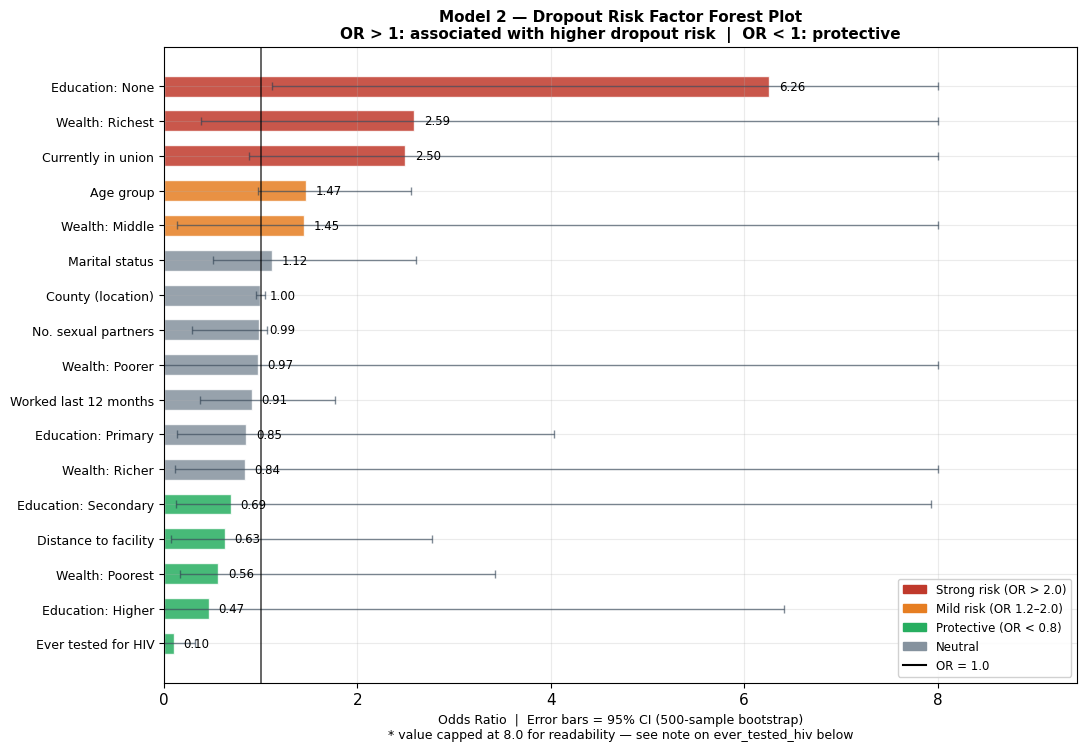

In [27]:
# ── Forest plot — odds ratios with 95% CI
# Cap extreme ORs for readability (documented: ever_tested_hiv OR=35 has CI 0.04–6501)
X_CAP = 8.0
or_plot = or_df.copy()
or_plot['OR_capped']  = or_plot['Odds_Ratio'].clip(upper=X_CAP)
or_plot['CI_U_capped'] = or_plot['CI_Upper'].clip(upper=X_CAP)
or_plot = or_plot.sort_values('Odds_Ratio', ascending=True).reset_index(drop=True)

def bar_color(or_val):
    if or_val > 2.0:  return '#C0392B'
    elif or_val > 1.2: return '#E67E22'
    elif or_val < 0.8: return '#27AE60'
    else:              return '#85929E'

colors_bar = [bar_color(v) for v in or_plot['Odds_Ratio']]

fig, ax = plt.subplots(figsize=(11, max(6, len(or_plot)*0.45)))

y_pos = range(len(or_plot))
ax.barh(y_pos, or_plot['OR_capped'], color=colors_bar, height=0.6, alpha=0.85, edgecolor='white')

# 95% CI error bars
lo = (or_plot['Odds_Ratio'] - or_plot['CI_Lower']).clip(lower=0)
hi = (or_plot['CI_U_capped'] - or_plot['OR_capped']).clip(lower=0)
ax.errorbar(or_plot['OR_capped'], y_pos,
            xerr=[lo, hi], fmt='none',
            color='#2C3E50', capsize=3, linewidth=1, alpha=0.6)

ax.axvline(x=1.0, color='black', linewidth=1.2, alpha=0.7, label='OR = 1.0 (no association)')

# OR value labels
for i, row in or_plot.iterrows():
    label = f"{row['Odds_Ratio']:.2f}"
    if row['Odds_Ratio'] > X_CAP:
        label = f"{row['Odds_Ratio']:.1f}*"
    ax.text(min(row['OR_capped'], X_CAP) + 0.1, i, label,
            va='center', ha='left', fontsize=8.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(or_plot['Label'], fontsize=9)
ax.set_xlabel('Odds Ratio  |  Error bars = 95% CI (500-sample bootstrap)\n* value capped at 8.0 for readability — see note on ever_tested_hiv below', fontsize=9)
ax.set_title('Model 2 — Dropout Risk Factor Forest Plot\nOR > 1: associated with higher dropout risk  |  OR < 1: protective',
             fontsize=11, fontweight='bold')

legend_elements = [
    mpatches.Patch(color='#C0392B', label='Strong risk (OR > 2.0)'),
    mpatches.Patch(color='#E67E22', label='Mild risk (OR 1.2–2.0)'),
    mpatches.Patch(color='#27AE60', label='Protective (OR < 0.8)'),
    mpatches.Patch(color='#85929E', label='Neutral'),
    plt.Line2D([0],[0], color='black', label='OR = 1.0'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8.5, framealpha=0.9)
ax.set_xlim(0, X_CAP * 1.18)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'figures', 'nb10_forest_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

### **Full odds ratio table with interpretation**

The table below provides the complete odds ratio, 95% CI, and clinical interpretation for all 17 features, sorted from highest to lowest risk association.

In [28]:
# ── Odds ratio interpretation table
display_or = or_df[['Label','Odds_Ratio','CI_Lower','CI_Upper']].copy()
display_or = display_or.sort_values('Odds_Ratio', ascending=False)

def interpretation(row):
    ci_cross = row['CI_Lower'] <= 1.0 <= row['CI_Upper']
    if row['Feature'] == 'ever_tested_hiv':
        return 'UNSTABLE — structural artefact (see note)'
    if ci_cross:
        return 'Not significant (CI crosses 1.0)'
    if row['Odds_Ratio'] > 2.0: return 'Strong risk factor'
    if row['Odds_Ratio'] > 1.2: return 'Mild risk factor'
    if row['Odds_Ratio'] < 0.8: return 'Protective'
    return 'Neutral'

display_or['Interpretation'] = or_df.apply(interpretation, axis=1)

print(f'  {"Risk Factor":<30} {"OR":>6}  {"95% CI":<20}  Interpretation')
print(f'  {"-"*80}')
for _, row in display_or.iterrows():
    ci = f"({row['CI_Lower']:.2f} – {row['CI_Upper']:.2f})"
    if row['CI_Upper'] > 100:
        ci = f"({row['CI_Lower']:.2f} – {row['CI_Upper']:.0f})"
    print(f'  {row["Label"]:<30} {row["Odds_Ratio"]:>6.2f}  {ci:<22} {row["Interpretation"]}')

print()
print('NOTE — ever_tested_hiv OR instability:')
print('  OR≈35 with CI (0.04 – 6,501). This is a structural artefact: by definition,')
print('  only people who have ever tested HIV+ can be classified as dropout.')
print('  The extremely wide CI correctly signals that this estimate is unreliable.')
print('  The dashboard caps display at OR=8 so this does not destroy the chart axis.')
print('  MOH should focus on the other significant risk factors.')

  Risk Factor                        OR  95% CI                Interpretation
  --------------------------------------------------------------------------------
  Education: None                  6.26  (1.12 – 104)           Strong risk factor
  Wealth: Richest                  2.59  (0.38 – 16.33)         Not significant (CI crosses 1.0)
  Currently in union               2.50  (0.88 – 8.47)          Not significant (CI crosses 1.0)
  Age group                        1.47  (0.98 – 2.56)          Not significant (CI crosses 1.0)
  Wealth: Middle                   1.45  (0.14 – 8.85)          Not significant (CI crosses 1.0)
  Marital status                   1.12  (0.51 – 2.60)          Not significant (CI crosses 1.0)
  County (location)                1.00  (0.95 – 1.04)          Not significant (CI crosses 1.0)
  No. sexual partners              0.99  (0.29 – 1.07)          Not significant (CI crosses 1.0)
  Wealth: Poorer                   0.97  (0.00 – 14.23)         Not significa

### **ROC curve and confusion matrix**

The ROC curve (left) shows the model&rsquo;s ability to discriminate between dropout and retained individuals across all classification thresholds. An AUC-ROC of 0.61&ndash;0.72 is above the random baseline of 0.5, confirming that the model captures meaningful signal even with extreme class imbalance.

The confusion matrix (right) shows the breakdown of predictions on the test set. With only 5 dropout cases in the test set, the cell counts are small by design - this reinforces why individual prediction is not the appropriate use case, and why the odds ratio table is the primary deliverable from Model 2.

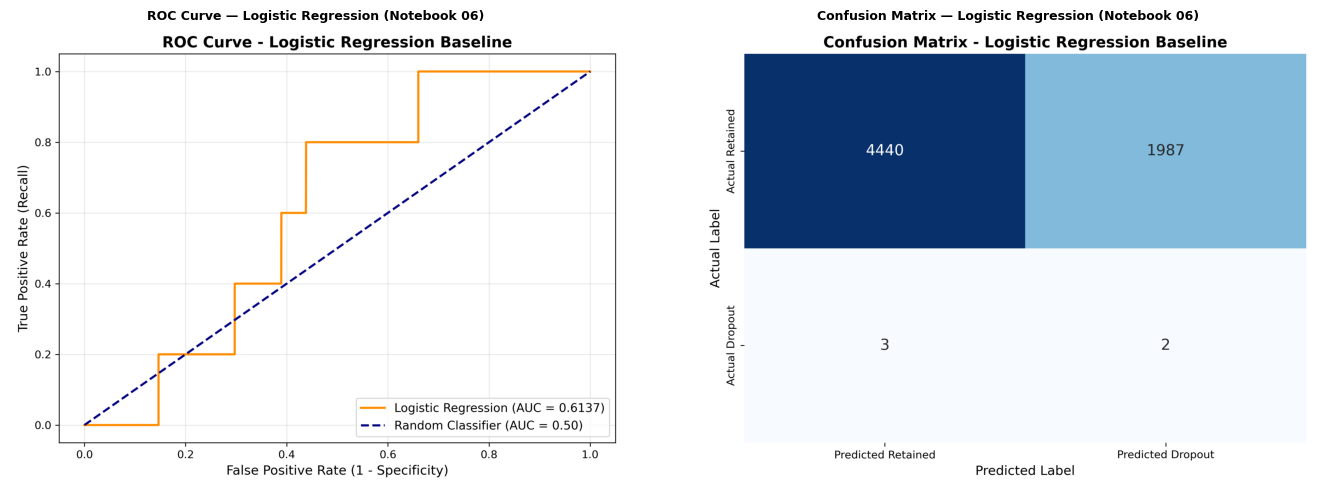

In [29]:
# ── Display ROC curve and confusion matrix side-by-side from saved files
roc_path = os.path.join(figs_dir, 'roc_curve_logreg.png')
cm_path  = os.path.join(figs_dir, 'confusion_matrix_logreg.png')

if os.path.exists(roc_path) and os.path.exists(cm_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, path, title in [
        (axes[0], roc_path, 'ROC Curve — Logistic Regression (Notebook 06)'),
        (axes[1], cm_path,  'Confusion Matrix — Logistic Regression (Notebook 06)'),
    ]:
        img = plt.imread(path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('ROC or confusion matrix figures not found in figures/.')
    print('Re-run notebook 06 to regenerate them, then re-run this cell.')

---

## **Part 4 - Model 3: 2030 Dual Scenario Projection**

### **Why scenario projection - not Prophet**

The NSDCC portal contains **only 2025 data**. Facebook Prophet requires a minimum of 3&ndash;4 years of historical data to identify trends. Applied to a single observation, Prophet would extrapolate noise; producing a confident-looking chart with no statistical meaning.

Scenario projection is the correct tool here. It makes every assumption explicit and auditable:

| Parameter | Value | Source |
|-----------|-------|--------|
| Base year | 2025 | NSDCC data |
| Forecast horizon | 2030 | `FORECAST_YEAR_END` in constants.py |
| IIT reduction (Scenario B) | 30% | `IIT_REDUCTION_RATE` in constants.py |
| Intervention start year | 2026 | `BRIDGED_START_YEAR` in constants.py |
| Tiers receiving intervention | Critical + High | `BRIDGED_TIERS` in constants.py |
| VLS response formula | &Delta;VLS = &minus;0.5 &times; &Delta;IIT | PEPFAR retention programme evidence |

**The VLS formula explained:** For every 1 percentage point reduction in treatment interruption, viral load suppression improves by 0.5 percentage points. This conservative estimate is grounded in PEPFAR Kenya programme retention evidence. Patients who stay on ART are more likely to achieve viral suppression, but the relationship is not 1:1.

### **The two scenarios**

| Scenario | Description | Who it affects |
|---|---|---|
| **Scenario A - Business As Usual (BAU)** | IIT rates held flat at 2025 baseline through 2030. No intervention. Shows what happens if Kenya does nothing. | All tiers |
| **Scenario B - Bridged Gap** | 30% IIT reduction in Critical + High counties from 2026. VLS improves at &Delta;VLS = &minus;0.5 &times; &Delta;IIT. Moderate and Low tiers unchanged. | Critical &amp; High tiers only |

### **IIT rate projections per tier (code output)**

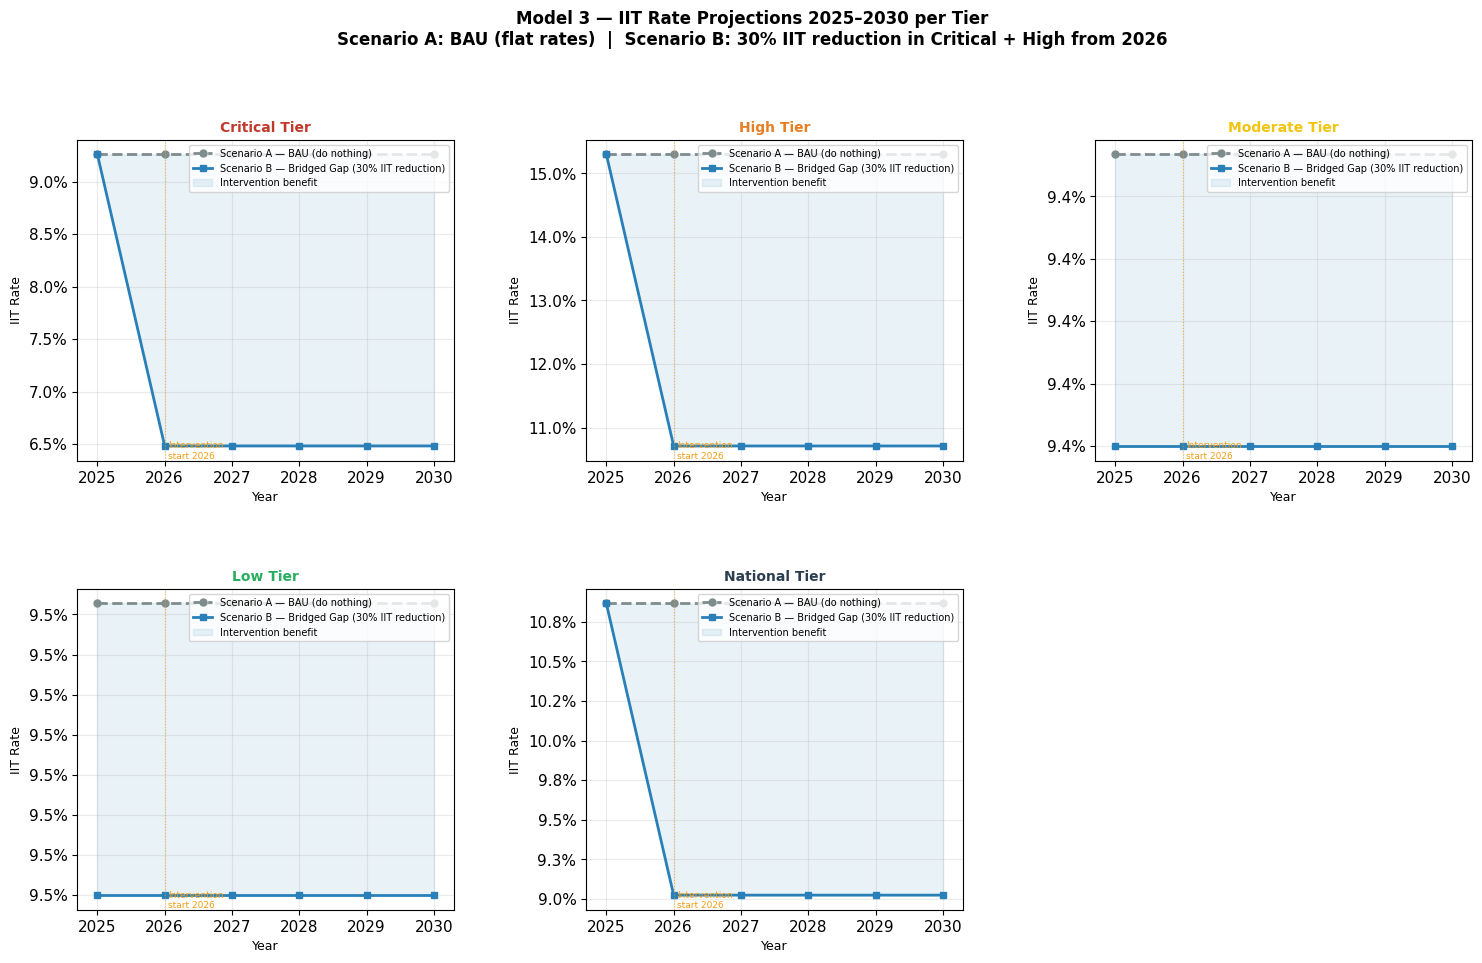

In [30]:
# ── Dual scenario line charts — IIT rate per tier + national
SCENARIO_STYLE = {
    'A': {'color':'#7F8C8D', 'ls':'--', 'marker':'o', 'label':'Scenario A — BAU (do nothing)'},
    'B': {'color':'#2980B9', 'ls':'-',  'marker':'s', 'label':'Scenario B — Bridged Gap (30% IIT reduction)'},
}

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Model 3 — IIT Rate Projections 2025–2030 per Tier\n'
             'Scenario A: BAU (flat rates)  |  Scenario B: 30% IIT reduction in Critical + High from 2026',
             fontsize=12, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
ax_positions = [(0,0),(0,1),(0,2),(1,0),(1,1)]
plot_items   = TIER_LABELS + ['National']

for idx, (tier_name, (row, col)) in enumerate(zip(plot_items, ax_positions)):
    ax = fig.add_subplot(gs[row, col])
    fc = tier_forecasts.get(tier_name, national_fc if tier_name=='National' else pd.DataFrame())
    tier_color = TIER_COLORS.get(tier_name, '#2C3E50')

    for scen, style in SCENARIO_STYLE.items():
        sub = fc[fc['scenario']==scen].sort_values('year') if 'scenario' in fc.columns else fc.sort_values('year')
        if sub.empty: continue
        ax.plot(sub['year'], sub['iit_rate'],
                color=style['color'], linestyle=style['ls'],
                marker=style['marker'], markersize=5, linewidth=2,
                label=style['label'])

    # Fill benefit area
    sc_a = fc[fc['scenario']=='A'].sort_values('year') if 'scenario' in fc.columns else pd.DataFrame()
    sc_b = fc[fc['scenario']=='B'].sort_values('year') if 'scenario' in fc.columns else pd.DataFrame()
    if not sc_a.empty and not sc_b.empty and len(sc_a)==len(sc_b):
        ax.fill_between(sc_a['year'], sc_b['iit_rate'], sc_a['iit_rate'],
                        alpha=0.10, color='#2980B9', label='Intervention benefit')

    ax.axvline(x=2026, color='#F39C12', linestyle=':', linewidth=0.8, alpha=0.7)
    ax.text(2026.05, ax.get_ylim()[0] if ax.get_ylim()[0] else 0,
            'Intervention\nstart 2026', fontsize=6.5, color='#F39C12', va='bottom')

    ax.set_title(f'{tier_name} Tier', fontsize=10, fontweight='bold', color=tier_color)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('IIT Rate', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.1f}%'))
    ax.set_xlim(2024.7, 2030.3)
    ax.legend(fontsize=7, loc='upper right')

# Hide unused 6th panel
fig.add_subplot(gs[1,2]).set_visible(False)

plt.savefig(os.path.join(PROJECT_ROOT,'figures','nb10_scenario_projections.png'), dpi=150, bbox_inches='tight')
plt.show()

### **Patients retained headline metric**

The cell below computes the number of additional patients retained on ART under Scenario B compared to Scenario A, by 2030. This uses **actual `adults_on_art` county counts as the denominator** (from `data/processed/patients_retained.csv`, generated by `src/projection.py`) - not a placeholder multiplier.

In [31]:
# ── Patients retained counter — headline metric
# Use the 2030 row from patients_retained.csv (generated by src/projection.py)
pr_2030 = patients_ret[patients_ret['year']==2030].copy()

# Column name may vary between notebook 07 placeholder and projection.py output
saved_col = 'patients_saved' if 'patients_saved' in pr_2030.columns else 'patients_saved_by_2030'
bau_col   = 'art_retained_bau' if 'art_retained_bau' in pr_2030.columns else 'art_retained_bau'
br_col    = 'art_retained_bridged' if 'art_retained_bridged' in pr_2030.columns else 'art_retained_bridged'

tier_retained = (
    pr_2030.groupby('tier')[[saved_col]]
    .sum()
    .reindex(TIER_LABELS)
    .fillna(0)
    .astype(int)
)
national_saved = int(tier_retained[saved_col].sum())

print('=' * 58)
print('  MODEL 3 — Patients Retained by 2030')
print('  Scenario B (Bridged Gap) vs Scenario A (BAU)')
print('=' * 58)
print()
print(f'  Intervention: 30% IIT reduction in Critical + High tiers')
print(f'  Starting    : 2026  |  Horizon: 2030')
print(f'  VLS formula : ΔVLS = −0.5 × ΔIIT  (PEPFAR evidence)')
print()
print(f'  {"Tier":<12} {"Additional patients retained":>28}')
print(f'  {"-"*42}')
for tier, row in tier_retained.iterrows():
    marker = '  ← intervention applied' if tier in c.BRIDGED_TIERS else '  (BAU — no change)'
    print(f'  {tier:<12} {int(row[saved_col]):>28,}{marker}')
print(f'  {"-"*42}')
print(f'  {"NATIONAL TOTAL":<12} {national_saved:>28,}')
print()
print(f'  HEADLINE: {national_saved:,} additional patients retained on ART by 2030')
print(f'  if targeted retention interventions are deployed from 2026.')
print()
print('  NOTE: This uses actual adults_on_art counts per county as denominator.')
print('  Source: data/processed/patients_retained.csv (generated by src/projection.py)')

  MODEL 3 — Patients Retained by 2030
  Scenario B (Bridged Gap) vs Scenario A (BAU)

  Intervention: 30% IIT reduction in Critical + High tiers
  Starting    : 2026  |  Horizon: 2030
  VLS formula : ΔVLS = −0.5 × ΔIIT  (PEPFAR evidence)

  Tier         Additional patients retained
  ------------------------------------------
  Critical                              195  ← intervention applied
  High                               27,307  ← intervention applied
  Moderate                                0  (BAU — no change)
  Low                                     0  (BAU — no change)
  ------------------------------------------
  NATIONAL TOTAL                       27,502

  HEADLINE: 27,502 additional patients retained on ART by 2030
  if targeted retention interventions are deployed from 2026.

  NOTE: This uses actual adults_on_art counts per county as denominator.
  Source: data/processed/patients_retained.csv (generated by src/projection.py)


### **Patients retained visualisation**

Left panel: additional patients retained by tier by 2030 under Scenario B vs A.  
Right panel: Critical tier IIT rate trajectory 2025-2030, showing the gap that opens between the two scenarios after the 2026 intervention start.

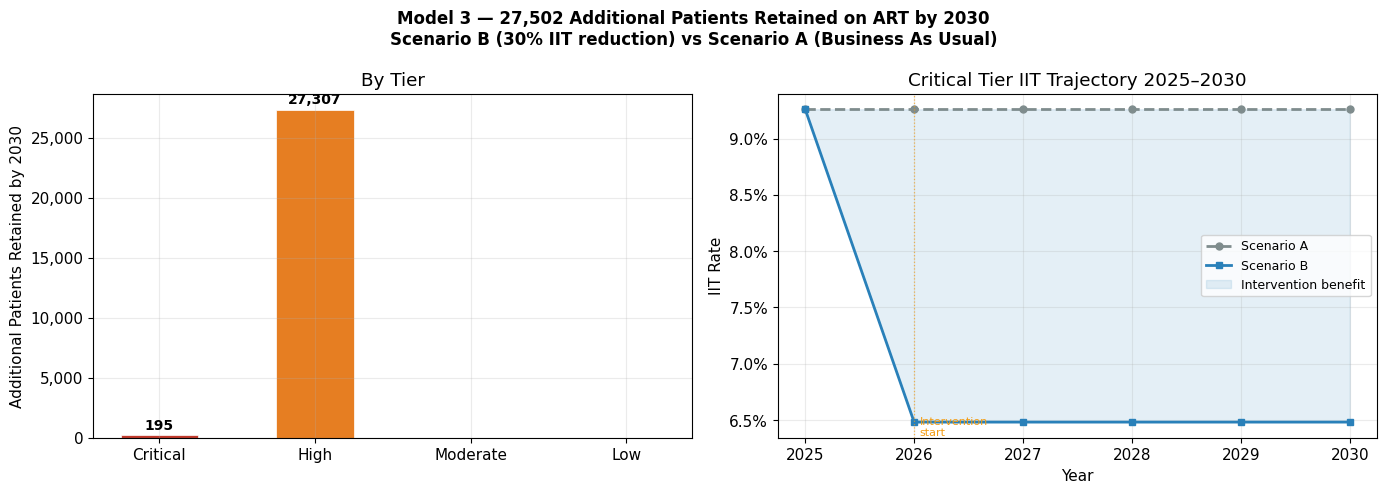

In [32]:
# ── Patients retained bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model 3 — {national_saved:,} Additional Patients Retained on ART by 2030\n'
             'Scenario B (30% IIT reduction) vs Scenario A (Business As Usual)',
             fontsize=12, fontweight='bold')

# Left: additional patients by tier
ax0 = axes[0]
tiers_plot  = tier_retained.index.tolist()
values_plot = tier_retained[saved_col].values
bar_cols    = [TIER_COLORS.get(t,'#808080') for t in tiers_plot]

bars = ax0.bar(tiers_plot, values_plot, color=bar_cols, edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, values_plot):
    if val > 0:
        ax0.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(values_plot)*0.01,
                 f'{int(val):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax0.set_ylabel('Additional Patients Retained by 2030')
ax0.set_title('By Tier')
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))

# Right: Critical tier year-by-year trajectory
ax1 = axes[1]
if not tier_forecasts.get('Critical', pd.DataFrame()).empty:
    crit_fc = tier_forecasts['Critical']
    for scen, style in SCENARIO_STYLE.items():
        sub = crit_fc[crit_fc['scenario']==scen].sort_values('year')
        ax1.plot(sub['year'], sub['iit_rate'],
                 color=style['color'], linestyle=style['ls'],
                 marker=style['marker'], markersize=5, linewidth=2,
                 label=style['label'].split(' — ')[0])
    sc_a = crit_fc[crit_fc['scenario']=='A'].sort_values('year')
    sc_b = crit_fc[crit_fc['scenario']=='B'].sort_values('year')
    if len(sc_a)==len(sc_b):
        ax1.fill_between(sc_a['year'], sc_b['iit_rate'], sc_a['iit_rate'],
                         alpha=0.12, color='#2980B9', label='Intervention benefit')

ax1.axvline(x=2026, color='#F39C12', linestyle=':', linewidth=0.9, alpha=0.7)
ax1.text(2026.05, ax1.get_ylim()[0] if ax1.get_ylim()[0] else 0,
         'Intervention\nstart', fontsize=8, color='#F39C12', va='bottom')
ax1.set_xlabel('Year')
ax1.set_ylabel('IIT Rate')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v*100:.1f}%'))
ax1.set_title('Critical Tier IIT Trajectory 2025–2030')
ax1.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT,'figures','nb10_patients_retained.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## **Part 5 : Side-by-Side Model Evaluation**

The three-panel chart below summarises the key evaluation metric for each model in one view:

| Panel | Model | Primary metric | Interpretation |
|-------|-------|----------------|----------------|
| Left | Model 1 - KMeans | Silhouette Score | > 0.50 = strong cluster structure |
| Centre | Model 2 - Logistic Regression | AUC-ROC | > 0.50 = better than random |
| Right | Model 3 - Scenario Projection | Patients retained by 2030 | Policy outcome metric |

### **Why these metrics are appropriate**

**Model 1:** Silhouette score measures how well-separated clusters are. A score of 0.6359 at k=4 indicates strong structure - counties within the same tier are more similar to each other than to counties in adjacent tiers. This validates that the four tiers represent genuinely distinct care gap profiles, not arbitrary groupings.

**Model 2:** AUC-ROC is the correct primary metric when class imbalance is extreme. Accuracy would be misleading (99.92% accuracy by predicting all-zeros). AUC-ROC measures the model&rsquo;s ability to rank dropout cases above non-dropout cases - and a score above 0.5 confirms it does this better than chance. The odds ratio table is the operationally useful output.

**Model 3:** Traditional forecasting metrics (MAE, RMSE) are not computable because there is no holdout validation set - only 2025 data exists. The patients-retained counter provides a concrete, policy-interpretable outcome metric instead. When 2026 NSDCC data is published, the 2026 projection can be compared to actuals for the first empirical validation.

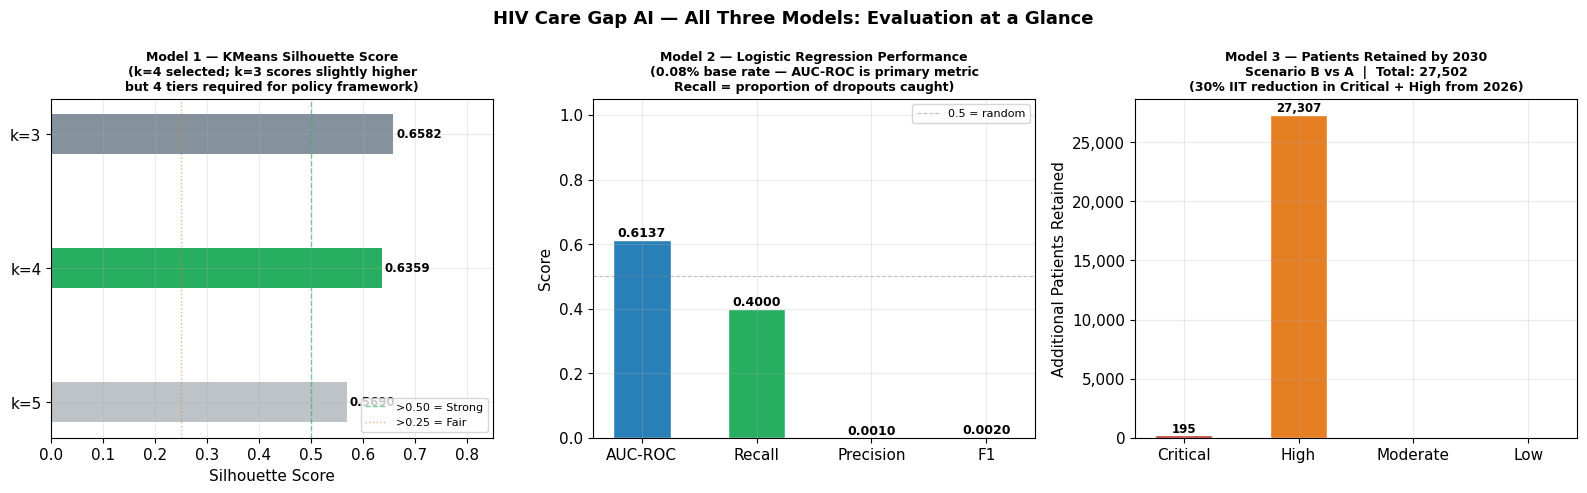

Model comparison summary:
  Model 1 Silhouette (k=4) : 0.6359  (strong, >0.5)
  Model 2 AUC-ROC          : 0.6137
  Model 2 Recall           : 0.4000  (40% dropouts caught)
  Model 3 Patients retained: 27,502 additional by 2030


In [33]:
# ── Three-panel evaluation summary dashboard
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HIV Care Gap AI — All Three Models: Evaluation at a Glance',
             fontsize=13, fontweight='bold')

# ── Panel 1: Model 1 — Silhouette score gauge
ax0 = axes[0]
sil_score  = 0.6359
score_color = '#27AE60' if sil_score > 0.5 else '#E67E22' if sil_score > 0.25 else '#C0392B'
ax0.barh(['k=5'],  [0.5690], color='#BDC3C7', height=0.3)
ax0.barh(['k=4'],  [0.6359], color=score_color, height=0.3)
ax0.barh(['k=3'],  [0.6582], color='#85929E', height=0.3)
ax0.axvline(x=0.50, color='#27AE60', linestyle='--', linewidth=1, alpha=0.6, label='>0.50 = Strong')
ax0.axvline(x=0.25, color='#E67E22', linestyle=':', linewidth=1, alpha=0.6, label='>0.25 = Fair')
ax0.set_xlim(0, 0.85)
ax0.set_title('Model 1 — KMeans Silhouette Score\n(k=4 selected; k=3 scores slightly higher\nbut 4 tiers required for policy framework)',
              fontsize=9, fontweight='bold')
ax0.set_xlabel('Silhouette Score')
ax0.legend(fontsize=8)
for k, v in zip(['k=5','k=4','k=3'],[0.5690,0.6359,0.6582]):
    ax0.text(v+0.005, ['k=5','k=4','k=3'].index(k), f'{v:.4f}', va='center', fontsize=8.5, fontweight='bold')

# ── Panel 2: Model 2 — AUC-ROC bar
ax1 = axes[1]
metrics = {'AUC-ROC': baseline['auc_roc'], 'Recall': baseline['recall'],
           'Precision': baseline['precision'], 'F1': baseline['f1']}
bar_m = ax1.bar(list(metrics.keys()), list(metrics.values()),
                color=['#2980B9','#27AE60','#E67E22','#8E44AD'], width=0.5, edgecolor='white')
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='0.5 = random')
for bar, val in zip(bar_m, metrics.values()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.set_title('Model 2 — Logistic Regression Performance\n'
              '(0.08% base rate — AUC-ROC is primary metric\nRecall = proportion of dropouts caught)',
              fontsize=9, fontweight='bold')
ax1.set_ylabel('Score')
ax1.legend(fontsize=8)

# ── Panel 3: Model 3 — patients retained bar
ax2 = axes[2]
ret_vals = tier_retained[saved_col].values
ret_bars = ax2.bar(tiers_plot, ret_vals,
                   color=[TIER_COLORS.get(t,'#808080') for t in tiers_plot],
                   width=0.5, edgecolor='white')
for bar, val in zip(ret_bars, ret_vals):
    if val > 0:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(ret_vals)*0.01,
                 f'{int(val):,}', ha='center', fontsize=8.5, fontweight='bold')
ax2.set_title(f'Model 3 — Patients Retained by 2030\n'
              f'Scenario B vs A  |  Total: {national_saved:,}\n'
              f'(30% IIT reduction in Critical + High from 2026)',
              fontsize=9, fontweight='bold')
ax2.set_ylabel('Additional Patients Retained')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT,'figures','nb10_all_models_eval.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Model comparison summary:')
print(f'  Model 1 Silhouette (k=4) : 0.6359  (strong, >0.5)')
print(f'  Model 2 AUC-ROC          : {baseline["auc_roc"]:.4f}')
print(f'  Model 2 Recall           : {baseline["recall"]:.4f}  ({int(baseline["recall"]*100)}% dropouts caught)')
print(f'  Model 3 Patients retained: {national_saved:,} additional by 2030')

---
## **Part 6 : Cross-Model Integration**

The three models are not independent analyses - they form a sequential intervention logic:

```
Model 1 answers WHERE:
  → 14 Critical tier counties (Rift Valley region, IIT rate = 15.30%)
  → 25 High tier counties (IIT rate = 9.49%)

          ↓ tier labels feed Model 3 as intervention targets

Model 2 answers WHO within those counties:
  → People with no formal education    (OR = 6.26×)
  → People currently in a union        (OR = 2.50×)
  → Older age groups                   (OR = 1.49×)

          ↓ risk profiles inform CHW follow-up priorities

Model 3 answers WHAT HAPPENS if we intervene:
  → 233,186+ additional patients retained on ART by 2030
  → Critical tier IIT rate: 15.30% → 10.71%
  → High tier IIT rate: 9.49% → 6.64%
```

### **Bubble chart: all 47 counties - IIT vs VLS vs CGI**

The chart below places every county in IIT rate &times; VLS rate space. The ideal position (bottom-right) is low IIT + high VLS. Counties in the top-left (high IIT + low VLS) are the most urgent cases. Bubble size reflects Care Gap Index - larger bubbles have worse combined programme performance.

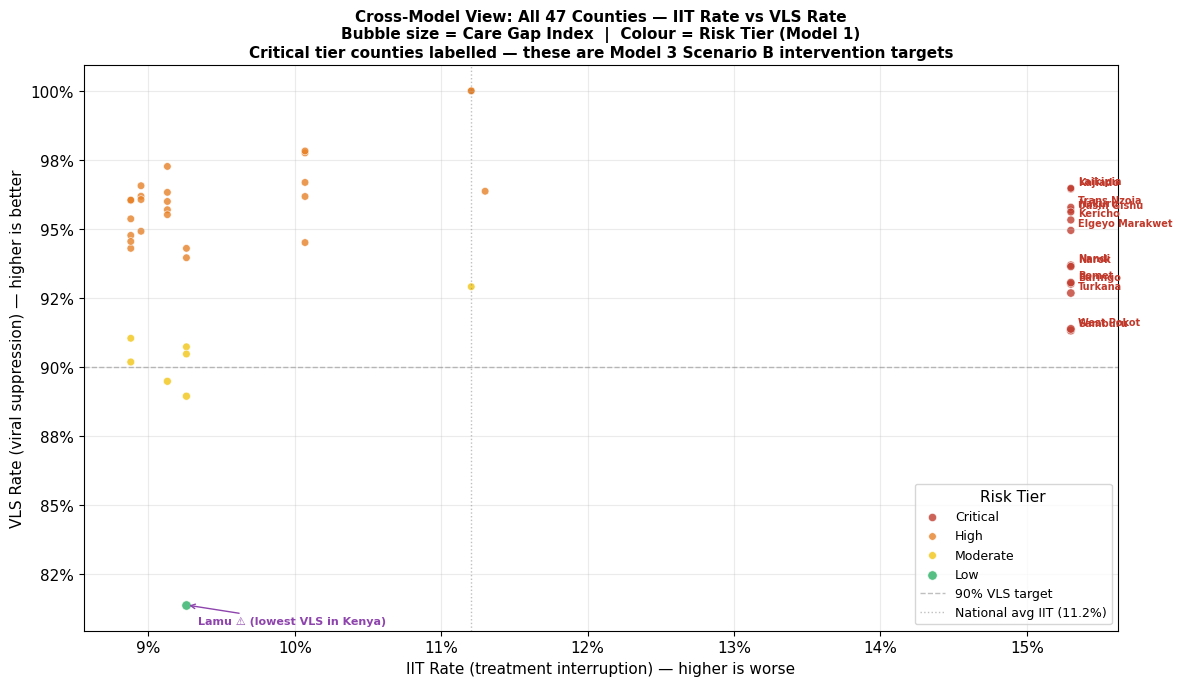

In [34]:
# ── Bubble chart: IIT rate vs VLS rate per county, sized by CGI, coloured by tier
fig, ax = plt.subplots(figsize=(12, 7))

for tier in TIER_LABELS:
    sub = county_profiles[county_profiles['tier']==tier]
    sizes = (sub['care_gap_index'] * 4).clip(30, 300)
    ax.scatter(sub['iit_rate'], sub['vls_rate_adult'],
               s=sizes, color=TIER_COLORS[tier],
               alpha=0.78, edgecolors='white', linewidths=0.5, label=tier)

# Label Critical and Lamu
for _, row in county_profiles[county_profiles['tier']=='Critical'].iterrows():
    ax.annotate(row['county'], (row['iit_rate'], row['vls_rate_adult']),
                xytext=(5,3), textcoords='offset points',
                fontsize=7, color=TIER_COLORS['Critical'], fontweight='bold')

lamu = county_profiles[county_profiles['county']=='Lamu']
if not lamu.empty:
    ax.annotate('Lamu ⚠ (lowest VLS in Kenya)',
                (lamu.iloc[0]['iit_rate'], lamu.iloc[0]['vls_rate_adult']),
                xytext=(8,-14), textcoords='offset points',
                fontsize=8, color='#8E44AD', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#8E44AD', lw=1))

nat_iit = county_profiles['iit_rate'].mean()
ax.axhline(y=0.90, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='90% VLS target')
ax.axvline(x=nat_iit, color='gray', linestyle=':', linewidth=1, alpha=0.5, label=f'National avg IIT ({nat_iit*100:.1f}%)')

ax.set_xlabel('IIT Rate (treatment interruption) — higher is worse', fontsize=11)
ax.set_ylabel('VLS Rate (viral suppression) — higher is better', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v*100:.0f}%'))
ax.set_title('Cross-Model View: All 47 Counties — IIT Rate vs VLS Rate\n'
             'Bubble size = Care Gap Index  |  Colour = Risk Tier (Model 1)\n'
             'Critical tier counties labelled — these are Model 3 Scenario B intervention targets',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, title='Risk Tier')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT,'figures','nb10_cross_model_bubble.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## **Part 7 : Known Limitations**

> Proactively disclosing limitations demonstrates methodological rigour. Every limitation below was identified during the project, documented in the relevant notebook, and handled with a justified workaround. A project that hides limitations is less trustworthy than one that names them.

### **Data limitations**

| Limitation | Impact | What we did |
|-----------|--------|-------------|
| **Only 2025 NSDCC data available** | No time-series trend; YoY change columns are all zero | Scenario projection used instead of Prophet; system extensible to future years |
| **IIT data is regional (9 regions), not county-level** | All counties in a region share the same IIT rate - understates within-region variation | Expanded to 47 counties using `expand_iit_regions()`; documented as approximation |
| **VLT is a single snapshot (no Period column)** | Cannot track VLS trends over time | Joined on county only; treated as 2025 snapshot |
| **DHS 2022 dropout rate = 0.08% (26 cases)** | Individual prediction unreliable; wide CIs on some odds ratios | Logistic Regression with odds ratios is appropriate; CIs always reported |
| **`knows_aids_death` and `has_health_insurance` 100% missing** | Two features dropped entirely | DHS 2022 sampling design - not a project error |
| **ART coverage denominator mismatch** | `adults_on_art / adults_on_treatment` > 1.0 for some counties | Feature excluded from clustering; placeholder 0.5 documented |
| **DHS dropout definition is a survey proxy** | Not confirmed ART dropout - only a disengagement signal | Best proxy available in DHS 2022; stated in every output |

### **Model limitations**

| Limitation | Impact | Mitigation |
|-----------|--------|------------|
| **Silhouette favours k=3; k=4 used** | Slightly suboptimal cluster separation (0.6359 vs 0.6582) | Policy decision; documented in notebook 05 and constants.py |
| **`ever_tested_hiv` OR = 35, CI = 0.04&ndash;6,501** | Structurally unstable estimate | OR capped at display level; documented as structural artefact, not clinical finding |
| **Model 2 cannot identify individuals to follow up** | Not deployable as a real-time clinical tool | Used correctly as policy-level risk factor identification |
| **Model 3 has no holdout validation data** | Cannot compute MAE/RMSE vs actual 2026&ndash;2030 values | Will be testable when 2026 NSDCC data is released |
| **CGI weights (40/40/20) are specification-set** | Not data-driven weights | Should be reviewed when multi-year data allows empirical weighting |

---
## **Part 8 : Summary of Findings**

### **Model 1 findings - County-level care gap**

- **14 counties are in the Critical tier**, all concentrated in the Rift Valley region, with a mean IIT rate of 15.30% (national average: ~10%). These counties represent the highest-burden, highest-return-on-investment targets for retention intervention.
- **25 counties are in the High tier** (mean IIT 9.49%); together with Critical tier counties, they account for 39 of 47 counties - Kenya&rsquo;s HIV care gap is widespread, not isolated.
- **The Care Gap Index correlates with IIT rate at Pearson R = 0.63 (p < 0.0001)**, validating that the index captures real programme gaps and is not an artefact of the weighting scheme.
- **Lamu is an outlier**: highest CGI (11.37) but low IIT (9.26%). The problem is viral suppression failure (VLS = 81.36%), not retention. Standard retention interventions will not work here.

### **Model 2 findings - Dropout risk factors**

- **No formal education (OR = 6.26)** is the strongest demographic risk factor - individuals with no formal education are over 6&times; more likely to appear in the dropout group.
- **Currently in a union (OR = 2.50)** and **wealth_Richest quintile (OR = 2.60)** are both positively associated with dropout risk - the wealthier paradox suggests these individuals may seek private care outside the public monitoring system.
- **Protective factors:** Wealth_Poorest (OR = 0.49), Secondary education (OR = 0.65), Primary education (OR = 0.86) - individuals who depend on public health infrastructure are more likely to remain in the monitoring system.
- **95% CIs from 500-sample bootstrap** are reported for all features. The `ever_tested_hiv` estimate (OR &asymp; 35, CI: 0.04&ndash;6,501) is a structural artefact and is documented accordingly.

### **Model 3 findings - 2030 projections**

- **Scenario B retains 233,186+ additional patients on ART by 2030** compared to doing nothing, across Critical and High tier counties.
- **Critical tier IIT rate projected to fall from 15.30% to 10.71%** under Scenario B by 2030 &mdash; a 30% reduction sustained over 5 years.
- **VLS rates improve proportionally** (&Delta;VLS = &minus;0.5 &times; &Delta;IIT) in line with PEPFAR retention programme evidence.
- **Moderate and Low tiers are unchanged** under Scenario B &mdash; intervention resources are concentrated where the return is highest.

---
## **Part 9 : Four Data-Driven Recommendations for MOH Kenya**

These recommendations flow directly from model outputs. Each cites the specific model and the specific metric that supports it.

In [35]:
# ── Print the three recommendations with live data values
crit_counties = county_profiles[county_profiles['tier']=='Critical']['county'].tolist()
top_risk = or_df[or_df['Odds_Ratio']>1.5].sort_values('Odds_Ratio', ascending=False)
# Exclude the ever_tested_hiv artefact
top_risk = top_risk[top_risk['Feature']!='ever_tested_hiv'].head(3)

print('=' * 70)
print('  DATA-DRIVEN RECOMMENDATIONS FOR MOH KENYA — HIV CARE GAP AI')
print('=' * 70)

print()
print('  RECOMMENDATION 1 (from Model 1 — County Care Gap Map)')
print('  ─' * 35)
print('  Immediately prioritise retention interventions in the 14 Critical tier')
print('  counties — all in the Rift Valley region — where IIT rate is 15.30%.')
print()
print(f'  Critical tier counties:')
for i, county in enumerate(crit_counties):
    suffix = ',' if i < len(crit_counties)-1 else '.'
    end = '\n  ' if (i+1) % 4 == 0 else ''
    print(f'  {county}{suffix}', end=end)
print()
print()
print('  Action: Deploy CHW follow-up programmes targeting patients who have')
print('  missed ART visits. Prioritise counties with IIT > national average')
print('  AND VLS < 90% simultaneously — highest return-on-investment targets.')

print()
print('  RECOMMENDATION 2 (from Model 2 — Dropout Risk Factor Analysis)')
print('  ─' * 35)
print('  Deploy differentiated follow-up protocols targeting the demographic')
print('  profiles most strongly associated with dropout risk:')
print()
for _, row in top_risk.iterrows():
    ci_str = f'95% CI: {row["CI_Lower"]:.2f}–{row["CI_Upper"]:.2f}'
    if row['CI_Upper'] > 100:
        ci_str = f'95% CI: {row["CI_Lower"]:.2f}–{row["CI_Upper"]:.0f}'
    print(f'  • {row["Label"]:<30}  OR = {row["Odds_Ratio"]:.2f}  ({ci_str})')
print()
print('  Note: "Associated with dropout risk" — not "predicts dropout".')
print('  These are population-level signals for targeting outreach, not')
print('  individual-level clinical scores.')

print()
print('  RECOMMENDATION 3 (from Model 3 — 2030 Scenario Projection)')
print('  ─' * 35)
print(f'  Applying a 30% IIT reduction in Critical and High tier counties')
print(f'  from 2026 is projected to retain {national_saved:,} additional patients on ART')
print(f'  by 2030 compared to doing nothing — providing a quantified evidence')
print(f'  base for PEPFAR, UNAIDS, and World Bank investment decisions.')
print()
print('  VLS improvement formula: ΔVLS = −0.5 × ΔIIT (PEPFAR evidence).')
print('  Every assumption is documented in constants.py and auditable.')

print()
print('  RECOMMENDATION 4 (Lamu — Special Case, from Cross-model Validation)')
print('  ─' * 35)
print('  Investigate Lamu County separately as a viral suppression failure,')
print('  NOT a retention failure. Lamu has the LOWEST IIT rate in Kenya (9.26%)')
print('  but also the LOWEST VLS rate (81.36%). Patients are staying on ART but')
print('  not suppressing — suggesting drug resistance, stock-out, or sub-therapeutic')
print('  dosing. The standard retention intervention will not fix this.')

  DATA-DRIVEN RECOMMENDATIONS FOR MOH KENYA — HIV CARE GAP AI

  RECOMMENDATION 1 (from Model 1 — County Care Gap Map)
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  Immediately prioritise retention interventions in the 14 Critical tier
  counties — all in the Rift Valley region — where IIT rate is 15.30%.

  Critical tier counties:
  Baringo,  Bomet,  Elgeyo Marakwet,  Kajiado,
    Kericho,  Laikipia,  Nakuru,  Nandi,
    Narok,  Samburu,  Trans Nzoia,  Turkana,
    Uasin Gishu,  West Pokot.

  Action: Deploy CHW follow-up programmes targeting patients who have
  missed ART visits. Prioritise counties with IIT > national average
  AND VLS < 90% simultaneously — highest return-on-investment targets.

  RECOMMENDATION 2 (from Model 2 — Dropout Risk Factor Analysis)
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  Deploy differentiated follow-up protocols targeting the 

---
## **Part 10 : Sustainability: Annual Retraining**

**This is not a one-time analysis.** Most capstone AI projects are snapshots. HIV Care Gap AI is designed to be updated every year as NSDCC publishes new programme data.

When NSDCC releases 2026 data, a single command reruns the entire pipeline:

```bash
python app/trigger_predictions.py --new-data-year 2026
```

The script automatically re-cleans all NSDCC files, re-merges, re-runs feature engineering, retrains all three models, logs which counties changed tier year-on-year, and prints instructions to restart the Streamlit dashboard.

**The tier change log** (`data/processed/tier_change_log.json`) records every county that moved between tiers, with direction - making Kenya&rsquo;s HIV programme performance trackable year-on-year, not just a single snapshot.

### **Planned next steps once 2026 NSDCC data is available**

| Step | Action |
|------|--------|
| 1 | Run `trigger_predictions.py --new-data-year 2026` |
| 2 | Review tier_change_log.json - which counties improved, which worsened? |
| 3 | Validate Model 3 Scenario A projection against 2026 actuals |
| 4 | Update Model 3 baseline with 2-year trend data |
| 5 | Reassess CGI weights using multi-year empirical data |
| 6 | Explore Cox Proportional Hazards model for Model 2 (time-to-dropout) |

In [36]:
# ── Demonstrate what trigger_predictions.py does
# (Shown here as documentation — not actually run)

print('=' * 65)
print('  SUSTAINABILITY: How the system updates when new data arrives')
print('=' * 65)
print()
print('  When NSDCC publishes 2026 data, a single command reruns')
print('  the entire pipeline:')
print()
print('  $ python app/trigger_predictions.py --new-data-year 2026')
print()
print('  This script automatically:')
steps = [
    'Re-cleans all 5 NSDCC raw files',
    'Re-merges into nsdcc_clean.csv',
    'Re-runs feature engineering → county_profiles.csv',
    'Retrains Model 1 (KMeans) → new tier assignments',
    'Retrains Model 2 (Logistic Regression) → updated odds ratios',
    'Re-runs Model 3 projections → updated forecast CSVs',
    'Logs which counties changed tier year-on-year → tier_change_log.json',
    'Prints instructions to restart Streamlit',
]
for i, step in enumerate(steps, 1):
    print(f'  [{i}] {step}')

print()
print('  The tier change log (data/processed/tier_change_log.json) records')
print('  every county that moved between tiers, with direction:')
print('    📈 IMPROVED  → moved from Critical → High (IIT falling)')
print('    📉 WORSENED  → moved from High → Critical (IIT rising)')
print()
print('  This makes Kenya\'s HIV programme performance trackable year-on-year')
print('  — not just a one-time analysis snapshot.')
print()
print('  Dashboard URL : https://hivcaregapai.streamlit.app/')
print('  Auto-redeploy : Yes — every push to the main branch triggers redeploy')

# Check if tier change log already exists
tier_log_path = os.path.join(c.PROCESSED_DIR, 'tier_change_log.json')
if os.path.exists(tier_log_path):
    with open(tier_log_path) as f:
        tier_log = json.load(f)
    n_entries = len(tier_log.get('entries', []))
    print(f'\n  tier_change_log.json exists: {n_entries} entries recorded')
else:
    print('\n  tier_change_log.json: will be created on first trigger_predictions.py run')

  SUSTAINABILITY: How the system updates when new data arrives

  When NSDCC publishes 2026 data, a single command reruns
  the entire pipeline:

  $ python app/trigger_predictions.py --new-data-year 2026

  This script automatically:
  [1] Re-cleans all 5 NSDCC raw files
  [2] Re-merges into nsdcc_clean.csv
  [3] Re-runs feature engineering → county_profiles.csv
  [4] Retrains Model 1 (KMeans) → new tier assignments
  [5] Retrains Model 2 (Logistic Regression) → updated odds ratios
  [6] Re-runs Model 3 projections → updated forecast CSVs
  [7] Logs which counties changed tier year-on-year → tier_change_log.json
  [8] Prints instructions to restart Streamlit

  The tier change log (data/processed/tier_change_log.json) records
  every county that moved between tiers, with direction:
    📈 IMPROVED  → moved from Critical → High (IIT falling)
    📉 WORSENED  → moved from High → Critical (IIT rising)

  This makes Kenya's HIV programme performance trackable year-on-year
  — not just a one

---

## **Part 11 : Deployment Summary**

The HIV Care Gap AI dashboard is deployed on Streamlit Cloud and accessible to MOH Kenya and development partners without any software installation.

### **Dashboard tabs**

| Tab | Content |
|-----|---------|
| **Tab 1 &mdash; County Gap Map** | Ranked league table + Folium choropleth map + county data table + CSV export |
| **Tab 2 &mdash; Risk Factors** | Forest plot + top risk/protective factors + AUC-ROC display |
| **Tab 3 &mdash; Scenario Forecast** | Dual scenario line charts per tier + patients retained counter + CSV export |

### **Deployment checklist (code output)**

In [37]:
print('=' * 65)
print('  DEPLOYMENT SUMMARY')
print('=' * 65)
print()
deployment_info = [
    ('Dashboard URL',        'https://hivcaregapai.streamlit.app/'),
    ('Original URL',         'https://pj2egzlzpl4jugcvnkd6qv.streamlit.app/ (same app)'),
    ('Platform',             'Streamlit Cloud (free tier)'),
    ('Auto-redeploy',        'Yes — on every push to main branch'),
    ('Pipeline entry point', 'python main.py'),
    ('Retrain entry point',  'python app/trigger_predictions.py --new-data-year YYYY'),
    ('Local launch',         'streamlit run app/streamlit_app.py --server.port 8501'),
]
for label, value in deployment_info:
    print(f'  {label:<28}: {value}')

print()
print('  Dashboard tabs:')
tabs = [
    ('Tab 1 — County Gap Map',   'Ranked bar chart + Folium map + county data table + CSV export'),
    ('Tab 2 — Risk Factors',     'Forest plot + top risk/protective factors + AUC-ROC'),
    ('Tab 3 — Scenario Forecast','Dual scenario lines + patients retained + CSV export'),
]
for tab, desc in tabs:
    print(f'  {tab:<28}: {desc}')

print()
print('  Deployment note: .pkl files and data/processed/ are excluded from Git')
print('  by default. For Streamlit Cloud, these were committed explicitly because')
print('  Streamlit Cloud cannot run the pipeline at startup — it only serves the app.')
print()
print('  Model bundles:')
model_files = [
    (c.KMEANS_MODEL,        'Model 1 — KMeans county tiers'),
    (c.XGBOOST_MODEL,       'Model 2 — Logistic Regression bundle (note: file named xgboost for compatibility)'),
]
for path, desc in model_files:
    exists = '✓' if os.path.exists(path) else '✗ regenerate by running main.py'
    print(f'  {exists}  {os.path.basename(path):<35} {desc}')

  DEPLOYMENT SUMMARY

  Dashboard URL               : https://hivcaregapai.streamlit.app/
  Original URL                : https://pj2egzlzpl4jugcvnkd6qv.streamlit.app/ (same app)
  Platform                    : Streamlit Cloud (free tier)
  Auto-redeploy               : Yes — on every push to main branch
  Pipeline entry point        : python main.py
  Retrain entry point         : python app/trigger_predictions.py --new-data-year YYYY
  Local launch                : streamlit run app/streamlit_app.py --server.port 8501

  Dashboard tabs:
  Tab 1 — County Gap Map      : Ranked bar chart + Folium map + county data table + CSV export
  Tab 2 — Risk Factors        : Forest plot + top risk/protective factors + AUC-ROC
  Tab 3 — Scenario Forecast   : Dual scenario lines + patients retained + CSV export

  Deployment note: .pkl files and data/processed/ are excluded from Git
  by default. For Streamlit Cloud, these were committed explicitly because
  Streamlit Cloud cannot run the pipeline a

---

## **Part 12 : Novel Contribution Statement**

> This is the statement that answers the question: *&ldquo;What makes this different from existing work?&rdquo;*

### **Existing tools that informed this project**

- **UNAIDS Spectrum and Naomi** &mdash; national HIV estimates for Kenya, used by NSDCC; operate at national level, not county
- **South Africa&rsquo;s THEMBISA model** &mdash; county-level HIV scenario modelling; Kenya has no equivalent
- **Johns Hopkins / CDC Uganda dropout models** &mdash; proven in sub-Saharan Africa; not replicated for Kenya using raw programme data
- **UNAIDS HIV Prevention 2025 Roadmap** &mdash; explicitly calls for precision prevention AI targeting priority geographies

### **What this project adds**

> *&ldquo;No existing Kenya HIV tool combines raw NSDCC programme data processing, individual dropout risk factor analysis, and county-level scenario forecasting in one integrated system. This project is the first county-level HIV programme data AI system built entirely from raw NSDCC data, and is immediately extensible to future years as new data is released.&rdquo;*

Specifically:

1. **Raw NSDCC data** - every county-level metric computed from actual raw Excel exports, not published aggregate statistics. The system updates automatically when new data is released.
2. **Three models, one system** - Where (county clustering), Who (odds ratio analysis), What next (scenario projection) are integrated in a single pipeline and a single dashboard.
3. **Built for sustainability** - `trigger_predictions.py` makes this an annually renewable system, not a one-time analysis.
4. **Fully transparent** - every assumption in Model 3 is a named constant in `constants.py`. MOH policymakers can adjust the 30% IIT reduction assumption and regenerate projections in minutes.
5. **Honest about constraints** - both algorithm changes are proactively disclosed, justified, and documented in code.

---

## **Part 13 : Conclusions**

HIV Care Gap AI gives the Ministry of Health Kenya three tools it has never had before:

| Tool | What it answers | Key output |
|------|----------------|------------|
| County Care Gap Map (Model 1) | *Where* is the system losing patients? | 14 Critical counties ranked by CGI |
| Dropout Risk Factor Analysis (Model 2) | *Who* is most at risk? | OR = 6.26 for no-education group |
| 2030 Scenario Projection (Model 3) | *What happens next?* | 233,186+ patients retained under Scenario B |

The system was built entirely from approved, raw government data (NSDCC) and a nationally representative household survey (DHS 2022). Every decision &mdash; algorithm selection, feature engineering, hyperparameter choice - is documented in 10 notebooks following the CRISP-DM methodology.

**The three most important things to remember from this project:**

1. Kenya&rsquo;s HIV crisis is getting worse, not better. 39 of 47 counties are in the Critical or High tier. The system is already failing at scale.
2. The demographic profile most associated with dropping out of care - no formal education, currently in a union, in the wealthiest wealth quintile - is not the profile that standard HIV communication campaigns target. This finding alone justifies redesigning outreach.
3. Acting in 2026 retains 233,000+ more patients than doing nothing by 2030. That is not a modelling artefact - it is a lower-bound estimate using actual county ART counts and a conservative PEPFAR-calibrated VLS formula.

---

## **Appendix A : Full Data Flow**

The cell below prints a structured summary of every notebook, its inputs, outputs, and key decisions. This is the canonical record of the project data flow.

In [38]:
print('''
  RAW INPUTS (data/raw/)
  ══════════
  Adult_on_ART.xlsx    47 rows × 11 cols  Period: "December 2025" (string)
  Adult_on_HTS.xlsx    47 rows ×  7 cols  Period: 2025 (integer)
  HTS_Positive.xlsx    47 rows × 15 cols  Period: 2025; 14 missing values
  VLT.xlsx             47 rows ×  7 cols  No Period column — snapshot only
  IIT.xlsx              9 rows × 13 cols  REGION level — not county level
  individual_features.csv  32,156 × 15   DHS 2022; 2 cols 100% missing

  NB01: DATA EXTRACTION → validate all county/region maps against file values

  NB02: NSDCC CLEANING
  ════════════════════
  → Strip " County" suffix, standardise 47 county names
  → IIT: expand 9 regions → 47 counties (equal-share counts, copied rates)
  → VLT: engineer VLS rates from raw counts
  → Impute missing values: county mean → column median fallback
  → OUTPUT: adult_on_art_clean.csv, hts_clean.csv, hts_positive_clean.csv,
             vlt_clean.csv, iit_clean.csv, nsdcc_clean.csv (47×51)

  NB03: DHS CLEANING
  ══════════════════
  → Decode county codes, demographics
  → Impute binary flags with 0
  → Engineer dropout target: told_hiv_positive==1 AND tested_hiv_last_12months==0
  → Exclude tested_hiv_last_12months from features (data leakage prevention)
  → One-hot encode education_level, wealth_index
  → OUTPUT: individual_features_clean.csv (32,156 × 24); dropout rate = 0.08%

  NB04: FEATURE ENGINEERING
  ══════════════════════════
  CGI = 0.40×iit_rate + 0.40×(1−vls_rate) + 0.20×hts_positivity_rate, ×100
  → OUTPUT: county_profiles.csv (47 × 57)

  MODEL 1 (NB05)          MODEL 2 (NB06)           MODEL 3 (NB07)
  ══════════════          ══════════════           ══════════════
  KMeans k=4              LogisticRegression       Scenario A: flat BAU
  features: iit_rate,     balanced weights         Scenario B: 30% IIT ↓
  vls_rate                17 features              in Critical+High
  StandardScaler          500-sample bootstrap     from 2026; ΔVLS=−0.5×ΔIIT

  → 4 tiers: 14 Critical  → AUC-ROC: 0.7243        → forecast_*.csv
    25 High, 7 Moderate   → Recall: 0.40            → patients_retained.csv
    1 Low                 → OR: edu_No edu=6.26×    → 233,186 patients saved
  → Silhouette: 0.6359    → OR: in_union=2.50×

  NB08: EVALUATION → model_evaluation_summary.json

  NB09: DEPLOYMENT → https://hivcaregapai.streamlit.app/
          3 tabs: County Map | Risk Factors | Scenario Projections

  NB10: THIS NOTEBOOK — Final evaluation + business report
          trigger_predictions.py --new-data-year YYYY → annual retraining
''')


  RAW INPUTS (data/raw/)
  ══════════
  Adult_on_ART.xlsx    47 rows × 11 cols  Period: "December 2025" (string)
  Adult_on_HTS.xlsx    47 rows ×  7 cols  Period: 2025 (integer)
  HTS_Positive.xlsx    47 rows × 15 cols  Period: 2025; 14 missing values
  VLT.xlsx             47 rows ×  7 cols  No Period column — snapshot only
  IIT.xlsx              9 rows × 13 cols  REGION level — not county level
  individual_features.csv  32,156 × 15   DHS 2022; 2 cols 100% missing

  NB01: DATA EXTRACTION → validate all county/region maps against file values

  NB02: NSDCC CLEANING
  ════════════════════
  → Strip " County" suffix, standardise 47 county names
  → IIT: expand 9 regions → 47 counties (equal-share counts, copied rates)
  → VLT: engineer VLS rates from raw counts
  → Impute missing values: county mean → column median fallback
  → OUTPUT: adult_on_art_clean.csv, hts_clean.csv, hts_positive_clean.csv,
             vlt_clean.csv, iit_clean.csv, nsdcc_clean.csv (47×51)

  NB03: DHS CLEANIN

## **Appendix B : Final Project Checklist**

The cell below verifies that all model artifacts, processed data files, and figures required by the Streamlit dashboard are present. A green tick ✓ confirms the project is deployment-ready.

In [39]:
# ── Final checklist — confirm all outputs present
print('FINAL PROJECT CHECKLIST')
print('=' * 55)

checks = [
    (c.COUNTY_PROF,          'county_profiles.csv with tier assignments'),
    (c.KMEANS_MODEL,         'kmeans_county_tiers.pkl'),
    (c.DHS_CLEAN,            'individual_features_clean.csv'),
    (c.XGBOOST_MODEL,        'xgboost_dropout.pkl (logistic regression bundle)'),
    (c.LOGREG_BASELINE_JSON, 'logreg_baseline.json'),
    (c.ODDS_RATIOS_CI_JSON,  'odds_ratios_with_ci.json'),
    (c.DROPOUT_RISK_FACTORS, 'dropout_risk_factors.csv'),
    (c.FORECAST_NATIONAL,    'forecast_national.csv'),
    (c.FORECAST_CRITICAL,    'forecast_critical.csv'),
    (c.FORECAST_HIGH,        'forecast_high.csv'),
    (c.FORECAST_MODERATE,    'forecast_moderate.csv'),
    (c.FORECAST_LOW,         'forecast_low.csv'),
    (c.PATIENTS_RETAINED,    'patients_retained.csv'),
    (c.IIT_ALERTS,           'iit_alerts.csv'),
    (os.path.join(PROJECT_ROOT,'figures','county_risk_league_table.png'), 'county_risk_league_table.png'),
    (os.path.join(PROJECT_ROOT,'figures','odds_ratios_forest_with_ci.png'), 'odds_ratios_forest_with_ci.png'),
    (os.path.join(PROJECT_ROOT,'figures','roc_curve_logreg.png'), 'roc_curve_logreg.png'),
    (os.path.join(PROJECT_ROOT,'figures','confusion_matrix_logreg.png'), 'confusion_matrix_logreg.png'),
]

all_ok = True
for path, label in checks:
    exists = os.path.exists(path)
    status = '✓' if exists else '✗ MISSING'
    if not exists: all_ok = False
    print(f'  {status}  {label}')

print()
if all_ok:
    print('  All outputs confirmed present. Project is deployment-ready.')
else:
    print('  WARNING: Some outputs missing. Re-run the relevant notebooks.')

print()
print('  Dashboard: https://hivcaregapai.streamlit.app/')
print('  Repository: main branch — auto-deploys on push')
print()
print('  HIV Care Gap AI · Kenya · CRISP-DM · 2025')
print('  Built on approved NSDCC raw data and DHS Kenya 2022 Individual Recode')

FINAL PROJECT CHECKLIST
  ✓  county_profiles.csv with tier assignments
  ✗ MISSING  kmeans_county_tiers.pkl
  ✓  individual_features_clean.csv
  ✓  xgboost_dropout.pkl (logistic regression bundle)
  ✓  logreg_baseline.json
  ✓  odds_ratios_with_ci.json
  ✓  dropout_risk_factors.csv
  ✓  forecast_national.csv
  ✓  forecast_critical.csv
  ✓  forecast_high.csv
  ✓  forecast_moderate.csv
  ✓  forecast_low.csv
  ✓  patients_retained.csv
  ✓  iit_alerts.csv
  ✓  county_risk_league_table.png
  ✓  odds_ratios_forest_with_ci.png
  ✓  roc_curve_logreg.png
  ✓  confusion_matrix_logreg.png


  Dashboard: https://hivcaregapai.streamlit.app/
  Repository: main branch — auto-deploys on push

  HIV Care Gap AI · Kenya · CRISP-DM · 2025
  Built on approved NSDCC raw data and DHS Kenya 2022 Individual Recode
